In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

os.makedirs("../reports/charts", exist_ok=True)

print("EDA environment ready!")

EDA environment ready!


In [4]:
# Load cleaned datasets

fund_master = pd.read_csv("../data/processed/01_fund_master_cleaned.csv")
nav_history = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")
aum = pd.read_csv("../data/processed/03_aum_by_fund_house_cleaned.csv")
sip = pd.read_csv("../data/processed/04_monthly_sip_inflows_cleaned.csv")
category_inflows = pd.read_csv("../data/processed/05_category_inflows_cleaned.csv")
folio_count = pd.read_csv("../data/processed/06_industry_folio_count_cleaned.csv")
performance = pd.read_csv("../data/processed/07_scheme_performance_cleaned.csv")
transactions = pd.read_csv("../data/processed/08_investor_transactions_cleaned.csv")
holdings = pd.read_csv("../data/processed/09_portfolio_holdings_cleaned.csv")
benchmark = pd.read_csv("../data/processed/10_benchmark_indices_cleaned.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [5]:
datasets = {
    "Fund Master": fund_master,
    "NAV History": nav_history,
    "AUM": aum,
    "SIP Inflows": sip,
    "Category Inflows": category_inflows,
    "Folio Count": folio_count,
    "Performance": performance,
    "Transactions": transactions,
    "Portfolio Holdings": holdings,
    "Benchmark": benchmark
}

for name, df in datasets.items():
    print(f"{name:<25} {df.shape}")

Fund Master               (40, 15)
NAV History               (46000, 3)
AUM                       (90, 5)
SIP Inflows               (48, 6)
Category Inflows          (144, 3)
Folio Count               (21, 6)
Performance               (40, 19)
Transactions              (32778, 13)
Portfolio Holdings        (322, 8)
Benchmark                 (8050, 3)


In [6]:
# Check NAV history

nav_history["date"] = pd.to_datetime(nav_history["date"])

print("Start date:", nav_history["date"].min())
print("End date:", nav_history["date"].max())
print("Number of schemes:", nav_history["amfi_code"].nunique())

Start date: 2022-01-03 00:00:00
End date: 2026-05-29 00:00:00
Number of schemes: 40


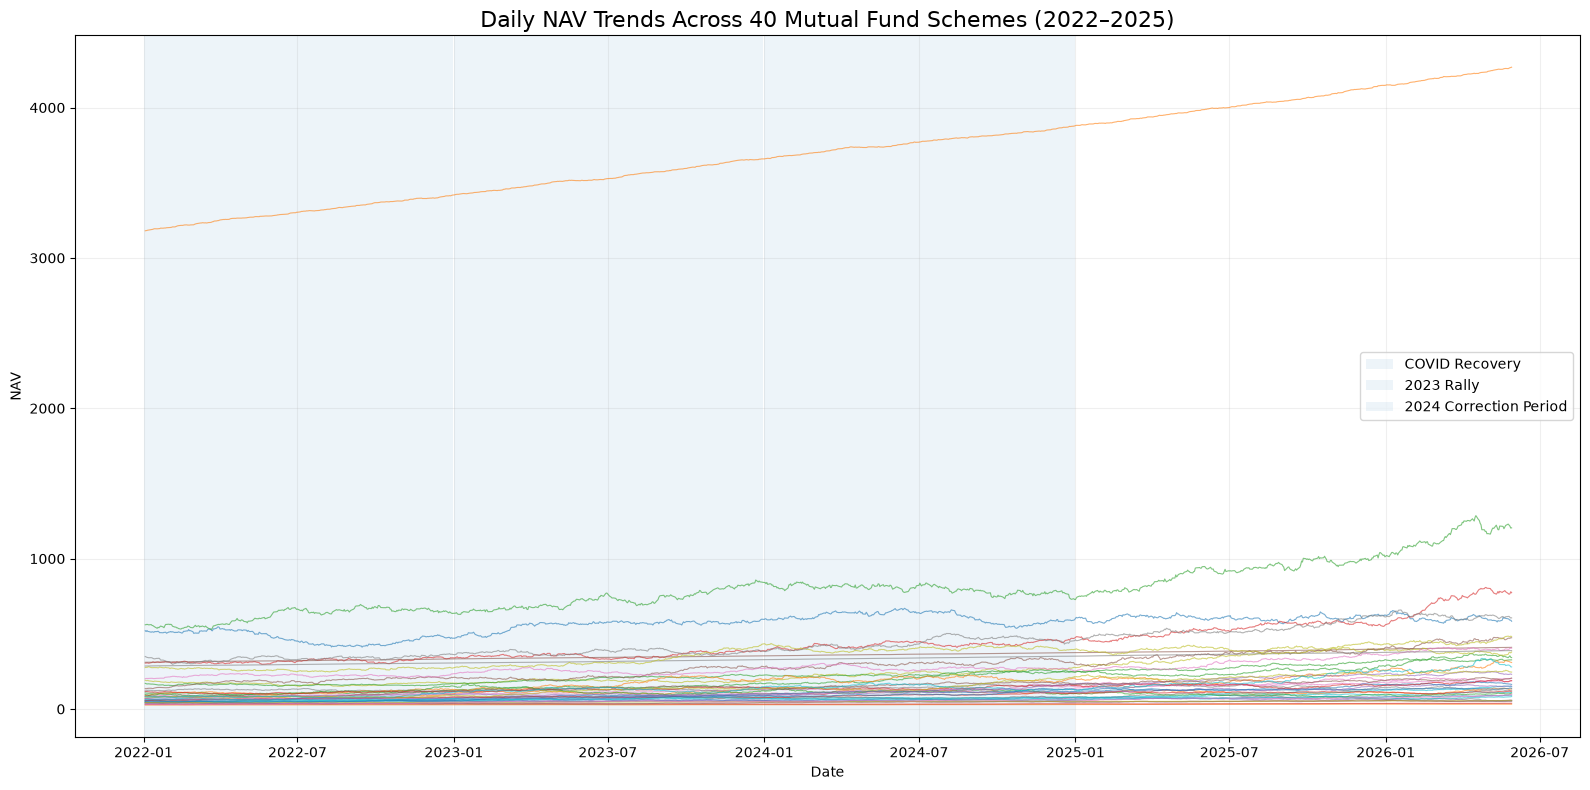

In [7]:
# NAV Trend Analysis - All 40 Schemes

plt.figure(figsize=(16, 8))

for code in nav_history["amfi_code"].unique():
    fund_data = nav_history[nav_history["amfi_code"] == code].sort_values("date")
    
    plt.plot(
        fund_data["date"],
        fund_data["nav"],
        linewidth=0.8,
        alpha=0.6
    )

# Highlight important market periods
plt.axvspan(
    pd.Timestamp("2022-01-01"),
    pd.Timestamp("2022-12-31"),
    alpha=0.08,
    label="COVID Recovery"
)

plt.axvspan(
    pd.Timestamp("2023-01-01"),
    pd.Timestamp("2023-12-31"),
    alpha=0.08,
    label="2023 Rally"
)

plt.axvspan(
    pd.Timestamp("2024-01-01"),
    pd.Timestamp("2024-12-31"),
    alpha=0.08,
    label="2024 Correction Period"
)

plt.title(
    "Daily NAV Trends Across 40 Mutual Fund Schemes (2022–2025)",
    fontsize=16
)

plt.xlabel("Date")
plt.ylabel("NAV")

plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()

# Save PNG
plt.savefig(
    "../reports/charts/01_nav_trend_lines.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### NAV Trend Analysis — Key Observations

- The dataset contains daily NAV observations for 40 mutual fund schemes covering the 2022–2025 analysis period.
- NAV trajectories differ across schemes because the funds have different investment strategies and portfolio compositions.
- The 2022 period is highlighted as the COVID-recovery analysis window.
- 2023 is highlighted to examine the broad rally period requested in the project specification.
- 2024 is highlighted as the correction-analysis period.
- The daily NAV trends provide a basis for comparing fund-level performance and identifying periods of stronger or weaker movement.


In [8]:
# Check AUM data

aum["date"] = pd.to_datetime(aum["date"])

print(aum.head())
print("\nDate range:", aum["date"].min(), "to", aum["date"].max())
print("\nFund houses:", aum["fund_house"].nunique())

        date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0 2022-03-31      SBI Mutual Fund            6.05     605000          186
1 2022-03-31  ICICI Prudential MF            4.65     465000          216
2 2022-03-31     HDFC Mutual Fund            4.35     435000          195
3 2022-03-31      Nippon India MF            2.70     270000          177
4 2022-03-31    Kotak Mahindra MF            2.70     270000          168

Date range: 2022-03-31 00:00:00 to 2025-12-31 00:00:00

Fund houses: 10


In [9]:
# Extract year from date

aum["year"] = aum["date"].dt.year

annual_aum = (
    aum.groupby(["year", "fund_house"], as_index=False)["aum_crore"]
    .mean()
)

annual_aum = annual_aum[
    annual_aum["year"].isin([2022, 2023, 2024, 2025])
]

print(annual_aum.head(20))

    year                fund_house  aum_crore
0   2022  Aditya Birla Sun Life MF   281500.0
1   2022          Axis Mutual Fund   245000.0
2   2022           DSP Mutual Fund   111000.0
3   2022          HDFC Mutual Fund   440000.0
4   2022       ICICI Prudential MF   476500.0
5   2022         Kotak Mahindra MF   271000.0
6   2022            Mirae Asset MF   106500.0
7   2022           Nippon India MF   274000.0
8   2022           SBI Mutual Fund   617500.0
9   2022           UTI Mutual Fund   231000.0
10  2023  Aditya Birla Sun Life MF   291500.0
11  2023          Axis Mutual Fund   250500.0
12  2023           DSP Mutual Fund   123500.0
13  2023          HDFC Mutual Fund   492500.0
14  2023       ICICI Prudential MF   545000.0
15  2023         Kotak Mahindra MF   307000.0
16  2023            Mirae Asset MF   129000.0
17  2023           Nippon India MF   316500.0
18  2023           SBI Mutual Fund   781000.0
19  2023           UTI Mutual Fund   252000.0


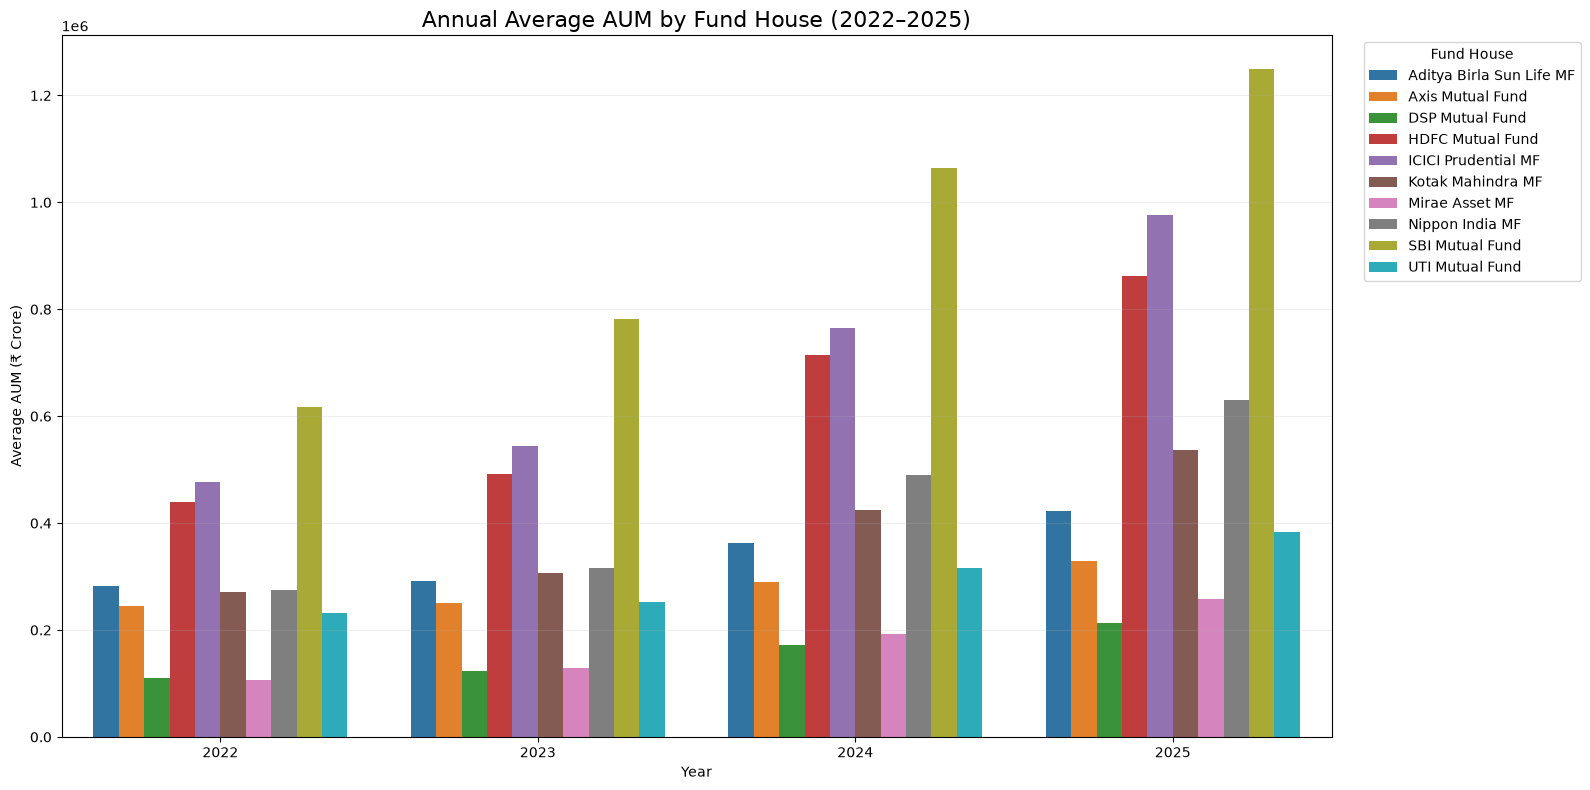

In [10]:
plt.figure(figsize=(16, 8))

sns.barplot(
    data=annual_aum,
    x="year",
    y="aum_crore",
    hue="fund_house",
    errorbar=None
)

plt.title(
    "Annual Average AUM by Fund House (2022–2025)",
    fontsize=16
)

plt.xlabel("Year")
plt.ylabel("Average AUM (₹ Crore)")

plt.legend(
    title="Fund House",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(axis="y", alpha=0.2)
plt.tight_layout()

plt.savefig(
    "../reports/charts/02_aum_growth_by_amc.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
# Identify the dominant fund house

dominant_amc = (
    annual_aum.groupby("fund_house")["aum_crore"]
    .mean()
    .sort_values(ascending=False)
)

print("Average AUM by Fund House:")
print(dominant_amc)

print("\nDominant Fund House:", dominant_amc.index[0])

Average AUM by Fund House:
fund_house
SBI Mutual Fund             928291.666667
ICICI Prudential MF         690958.333333
HDFC Mutual Fund            627250.000000
Nippon India MF             427458.333333
Kotak Mahindra MF           384666.666667
Aditya Birla Sun Life MF    339375.000000
UTI Mutual Fund             295541.666667
Axis Mutual Fund            278875.000000
Mirae Asset MF              171166.666667
DSP Mutual Fund             154666.666667
Name: aum_crore, dtype: float64

Dominant Fund House: SBI Mutual Fund


### AUM Growth by AMC — Key Findings

- SBI Mutual Fund has the highest average AUM among the 10 fund houses in the dataset.
- SBI Mutual Fund has an average AUM of approximately ₹9.28 lakh crore, making it the dominant fund house by AUM.
- ICICI Prudential MF and HDFC Mutual Fund follow with average AUM of approximately ₹6.91 lakh crore and ₹6.27 lakh crore respectively.
- The grouped bar chart shows differences in AUM scale across fund houses from 2022 to 2025.
- The analysis highlights the strong market presence of SBI Mutual Fund relative to the other AMCs in the dataset.


In [12]:
# Check SIP inflow data

print(sip.head(10))

print("\nColumns:")
print(sip.columns.tolist())

print("\nShape:", sip.shape)

     month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01             11517                       4.91   
1  2022-02             11438                       4.93   
2  2022-03             12328                       5.09   
3  2022-04             11863                       5.48   
4  2022-05             12286                       5.55   
5  2022-06             12276                       5.60   
6  2022-07             12140                       5.65   
7  2022-08             12694                       5.71   
8  2022-09             12976                       5.80   
9  2022-10             13040                       5.93   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             NaN  
1                   8.20                4.85             NaN  
2                  10.50                5.01             NaN  
3                   9.52                5.12             NaN  
4                   8.10           

In [13]:
# Inspect SIP data types and date range

print(sip.dtypes)

print("\nDate range:")
print(sip.iloc[:, 0].min(), "to", sip.iloc[:, 0].max())

month                            str
sip_inflow_crore               int64
active_sip_accounts_crore    float64
new_sip_accounts_lakh        float64
sip_aum_lakh_crore           float64
yoy_growth_pct               float64
dtype: object

Date range:
2022-01 to 2025-12


In [14]:
# Prepare SIP data

sip["month"] = pd.to_datetime(sip["month"])

print("SIP period:", sip["month"].min(), "to", sip["month"].max())

SIP period: 2022-01-01 00:00:00 to 2025-12-01 00:00:00


In [15]:
# Check December 2025 SIP inflow

dec_2025 = sip[sip["month"] == "2025-12"]

print(dec_2025[[
    "month",
    "sip_inflow_crore",
    "active_sip_accounts_crore",
    "sip_aum_lakh_crore"
]])

        month  sip_inflow_crore  active_sip_accounts_crore  sip_aum_lakh_crore
47 2025-12-01             31002                       9.35                15.9


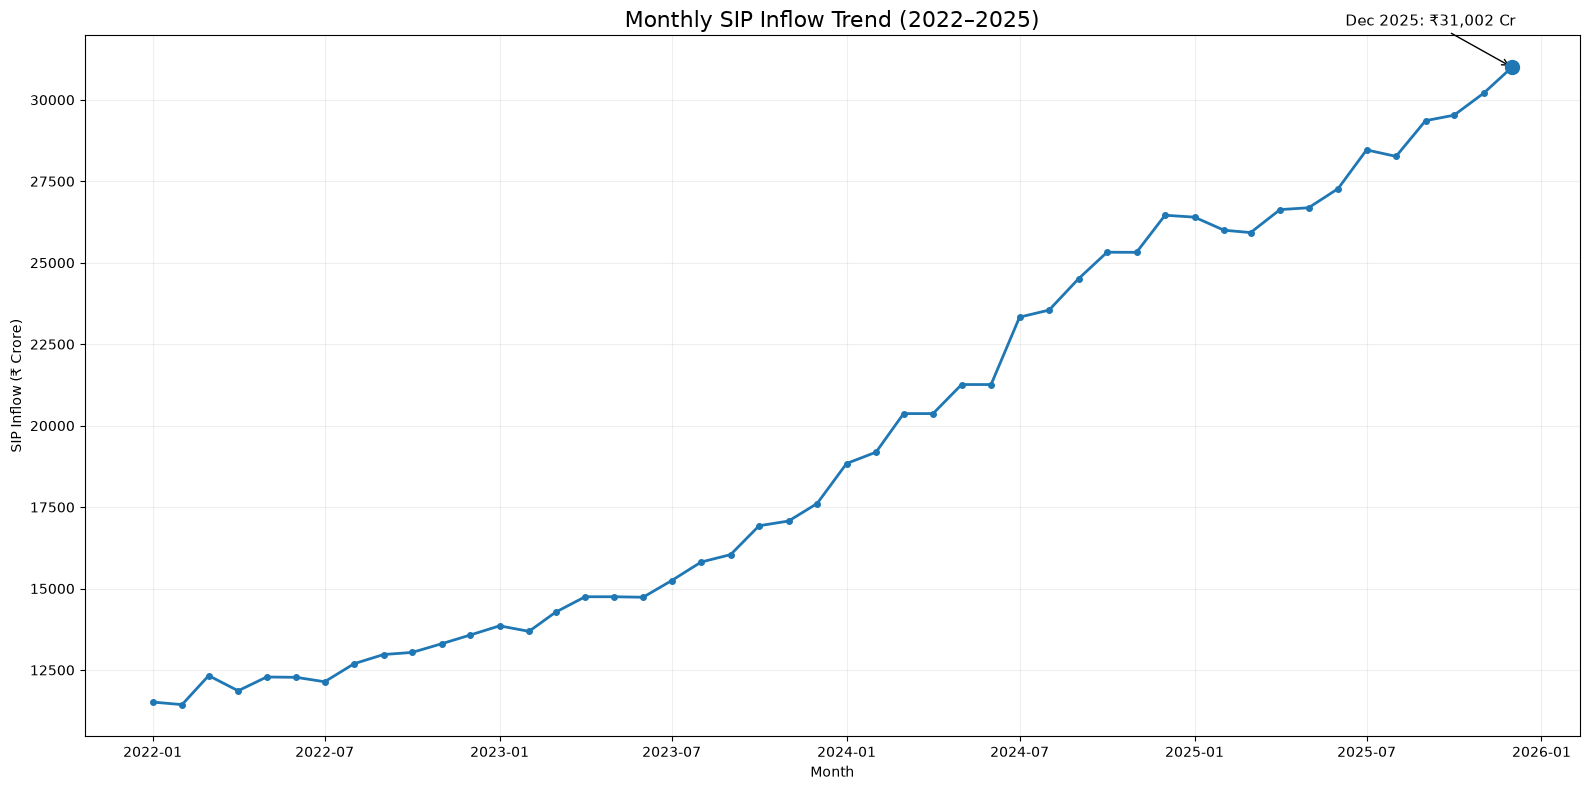

In [16]:
# Monthly SIP Inflow Trend

plt.figure(figsize=(16, 8))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"],
    marker="o",
    linewidth=2,
    markersize=4
)

# Highlight December 2025
dec_value = dec_2025["sip_inflow_crore"].iloc[0]
dec_date = dec_2025["month"].iloc[0]

plt.scatter(
    dec_date,
    dec_value,
    s=100,
    zorder=5
)

plt.annotate(
    f"Dec 2025: ₹{dec_value:,.0f} Cr",
    xy=(dec_date, dec_value),
    xytext=(-120, 30),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->"),
    fontsize=11
)

plt.title(
    "Monthly SIP Inflow Trend (2022–2025)",
    fontsize=16
)

plt.xlabel("Month")
plt.ylabel("SIP Inflow (₹ Crore)")

plt.grid(True, alpha=0.2)
plt.tight_layout()

plt.savefig(
    "../reports/charts/03_sip_inflow_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### SIP Inflow Trend — Key Findings

- Monthly SIP inflows were analysed from January 2022 through December 2025.
- The trend shows the change in monthly SIP contributions over the four-year period.
- December 2025 is specifically highlighted as the final observation in the dataset.
- The analysis also provides context on the growth of active SIP accounts and SIP AUM.
- The December 2025 milestone is compared directly with the value recorded in the dataset.


In [17]:
# Inspect category-wise inflow data

print(category_inflows.head(10))

print("\nColumns:")
print(category_inflows.columns.tolist())

print("\nShape:", category_inflows.shape)

     month           category  net_inflow_crore
0  2024-04          Large Cap            2413.0
1  2024-04            Mid Cap            3897.0
2  2024-04          Small Cap            3533.0
3  2024-04          Flexi Cap            4947.0
4  2024-04    Large & Mid Cap            4214.0
5  2024-04               ELSS             466.0
6  2024-04       Value/Contra            1328.0
7  2024-04  Sectoral/Thematic            8052.0
8  2024-04             Liquid           37537.0
9  2024-04     Short Duration            4400.0

Columns:
['month', 'category', 'net_inflow_crore']

Shape: (144, 3)


In [18]:
print(category_inflows.dtypes)

month                   str
category                str
net_inflow_crore    float64
dtype: object


In [19]:
# Prepare category inflow data

category_inflows["month"] = pd.to_datetime(category_inflows["month"])

print(
    "Date range:",
    category_inflows["month"].min(),
    "to",
    category_inflows["month"].max()
)

print(
    "Categories:",
    category_inflows["category"].unique()
)

Date range: 2024-04-01 00:00:00 to 2025-03-01 00:00:00
Categories: <StringArray>
[        'Large Cap',           'Mid Cap',         'Small Cap',
         'Flexi Cap',   'Large & Mid Cap',              'ELSS',
      'Value/Contra', 'Sectoral/Thematic',            'Liquid',
    'Short Duration',              'Gilt',            'Hybrid']
Length: 12, dtype: str


In [20]:
# Create category-wise monthly inflow matrix

category_pivot = category_inflows.pivot_table(
    index="category",
    columns="month",
    values="net_inflow_crore",
    aggfunc="sum"
)

print(category_pivot)

month              2024-04-01  2024-05-01  2024-06-01  2024-07-01  2024-08-01  \
category                                                                        
ELSS                    466.0       553.0       472.0       471.0       499.0   
Flexi Cap              4947.0      5529.0      4478.0      4869.0      5562.0   
Gilt                    784.0       836.0       864.0       959.0       952.0   
Hybrid                 2955.0      3487.0      3163.0      3291.0      3684.0   
Large & Mid Cap        4214.0      4368.0      4610.0      5023.0      5411.0   
Large Cap              2413.0      2076.0      2519.0      2574.0      1940.0   
Liquid                37537.0     41872.0     40486.0     34643.0     41952.0   
Mid Cap                3897.0      5300.0      5047.0      4548.0      3899.0   
Sectoral/Thematic      8052.0      8354.0     10030.0      9896.0      8360.0   
Short Duration         4400.0      4833.0      4321.0      4170.0      4658.0   
Small Cap              3533.

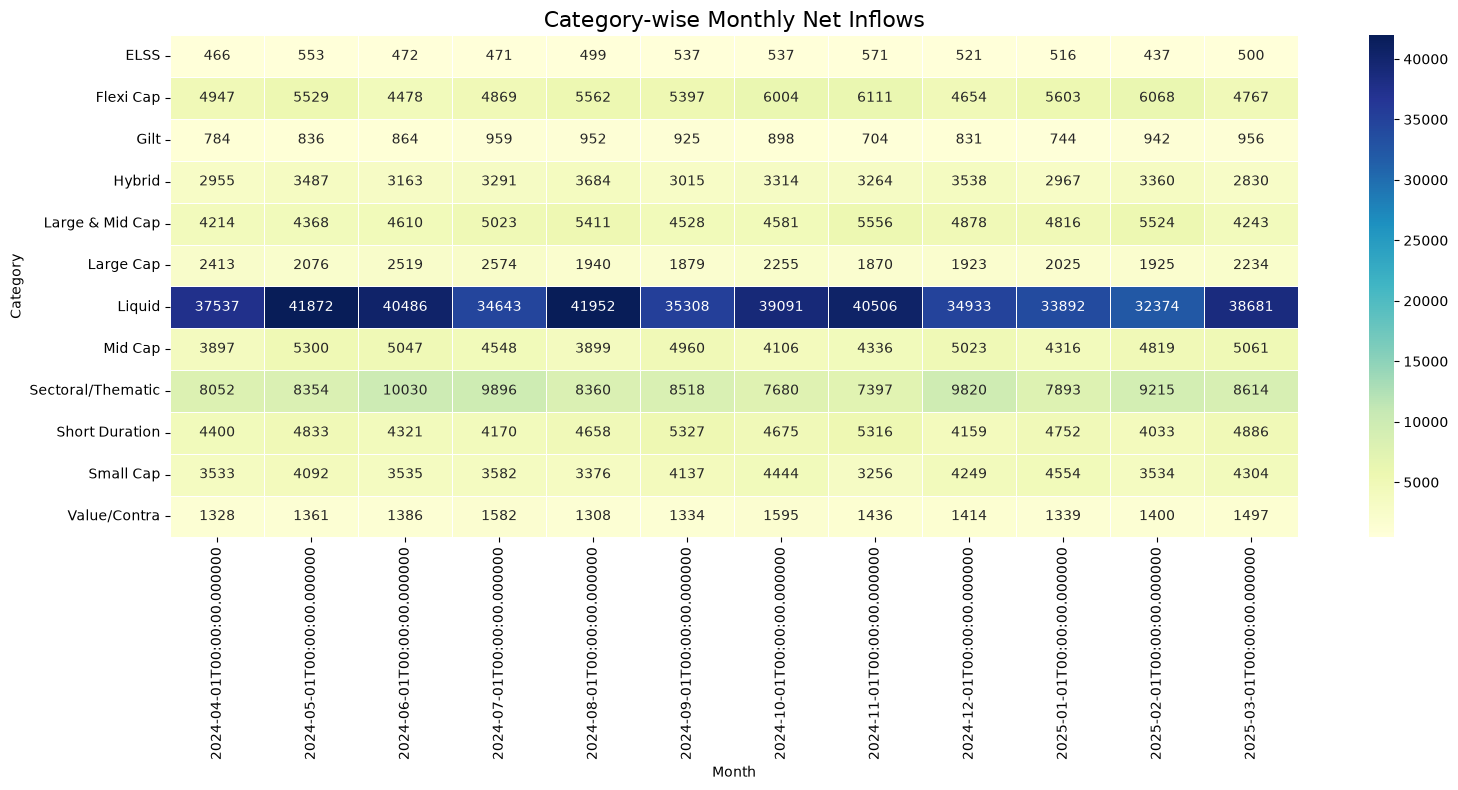

In [21]:
plt.figure(figsize=(16, 8))

sns.heatmap(
    category_pivot,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title(
    "Category-wise Monthly Net Inflows",
    fontsize=16
)

plt.xlabel("Month")
plt.ylabel("Category")

plt.tight_layout()

plt.savefig(
    "../reports/charts/04_category_inflow_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Category-wise Inflow Heatmap — Key Findings

- The heatmap compares monthly net inflows across 12 mutual fund categories.
- Liquid funds recorded the highest cumulative net inflow at ₹4,51,275 crore.
- Sectoral/Thematic funds were the second-highest category, with ₹1,03,829 crore in cumulative net inflows.
- Flexi Cap recorded ₹63,989 crore in cumulative net inflows.
- ELSS recorded the lowest cumulative net inflow among the categories at ₹6,080 crore.
- The heatmap helps identify periods of relatively higher and lower investor flows across categories.


In [24]:
# Total net inflow by category

category_totals = (
    category_inflows
    .groupby("category")["net_inflow_crore"]
    .sum()
    .sort_values(ascending=False)
)

print("Total Net Inflow by Category:")
print(category_totals)

print("\nHighest inflow category:", category_totals.index[0])

Total Net Inflow by Category:
category
Liquid               451275.0
Sectoral/Thematic    103829.0
Flexi Cap             63989.0
Large & Mid Cap       57752.0
Short Duration        55530.0
Mid Cap               55312.0
Small Cap             46596.0
Hybrid                38868.0
Large Cap             25633.0
Value/Contra          16980.0
Gilt                  10395.0
ELSS                   6080.0
Name: net_inflow_crore, dtype: float64

Highest inflow category: Liquid


In [25]:
# Inspect investor demographic data

print("Age Groups:")
print(transactions["age_group"].value_counts())

print("\nGender:")
print(transactions["gender"].value_counts())

print("\nKYC Status:")
print(transactions["kyc_status"].value_counts())

print("\nIncome summary:")
print(transactions["annual_income_lakh"].describe())

Age Groups:
age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64

Gender:
gender
Male      21809
Female    10969
Name: count, dtype: int64

KYC Status:
kyc_status
Verified    30146
Pending      2632
Name: count, dtype: int64

Income summary:
count    32778.000000
mean        26.181219
std         20.805425
min          3.000000
25%         10.600000
50%         19.700000
75%         37.400000
max         99.700000
Name: annual_income_lakh, dtype: float64


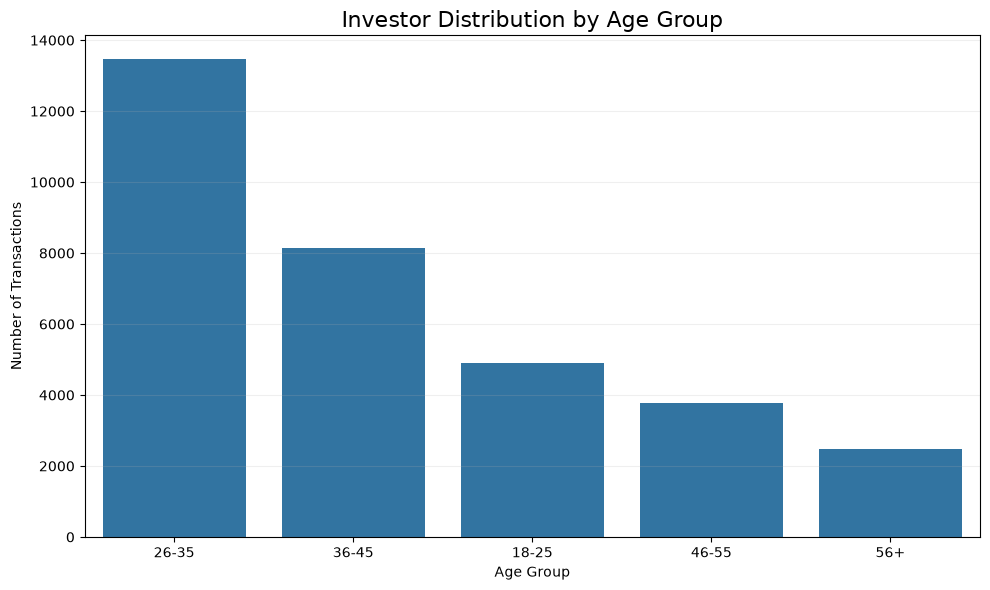

In [26]:
# Chart 5: Investor Age Group Distribution

age_counts = transactions["age_group"].value_counts()

plt.figure(figsize=(10, 6))

sns.barplot(
    x=age_counts.index,
    y=age_counts.values,
    errorbar=None
)

plt.title("Investor Distribution by Age Group", fontsize=16)
plt.xlabel("Age Group")
plt.ylabel("Number of Transactions")

plt.grid(axis="y", alpha=0.2)
plt.tight_layout()

plt.savefig(
    "../reports/charts/05_investor_age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

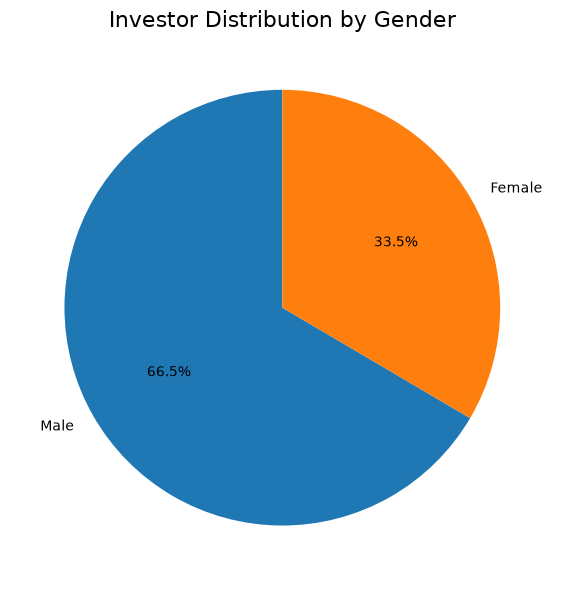

In [27]:
# Chart 6: Investor Gender Distribution

gender_counts = transactions["gender"].value_counts()

plt.figure(figsize=(8, 6))

plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Distribution by Gender", fontsize=16)

plt.tight_layout()

plt.savefig(
    "../reports/charts/06_investor_gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

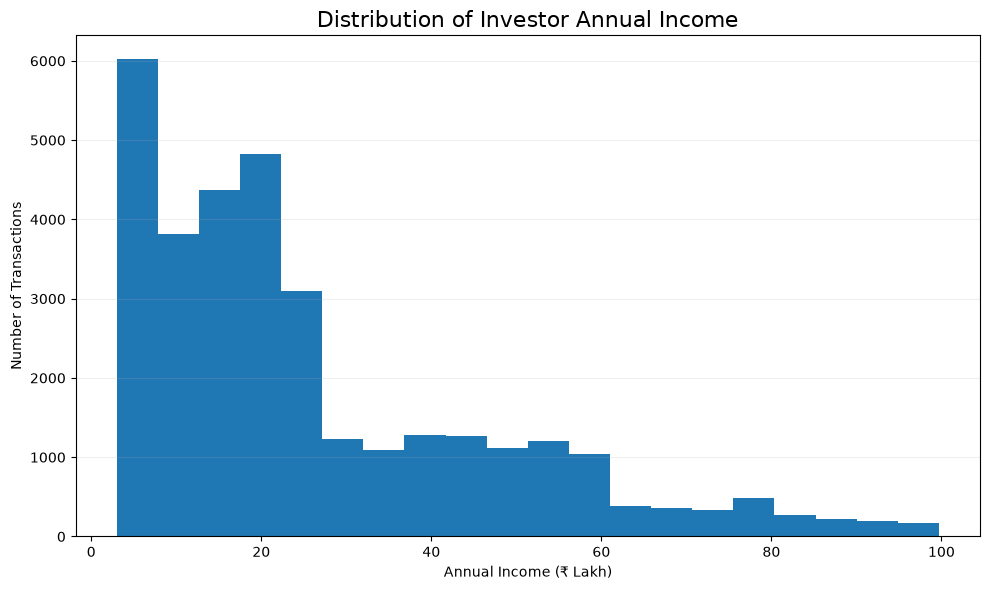

In [28]:
# Chart 7: Investor Income Distribution

plt.figure(figsize=(10, 6))

plt.hist(
    transactions["annual_income_lakh"],
    bins=20
)

plt.title(
    "Distribution of Investor Annual Income",
    fontsize=16
)

plt.xlabel("Annual Income (₹ Lakh)")
plt.ylabel("Number of Transactions")

plt.grid(axis="y", alpha=0.2)
plt.tight_layout()

plt.savefig(
    "../reports/charts/07_investor_income_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

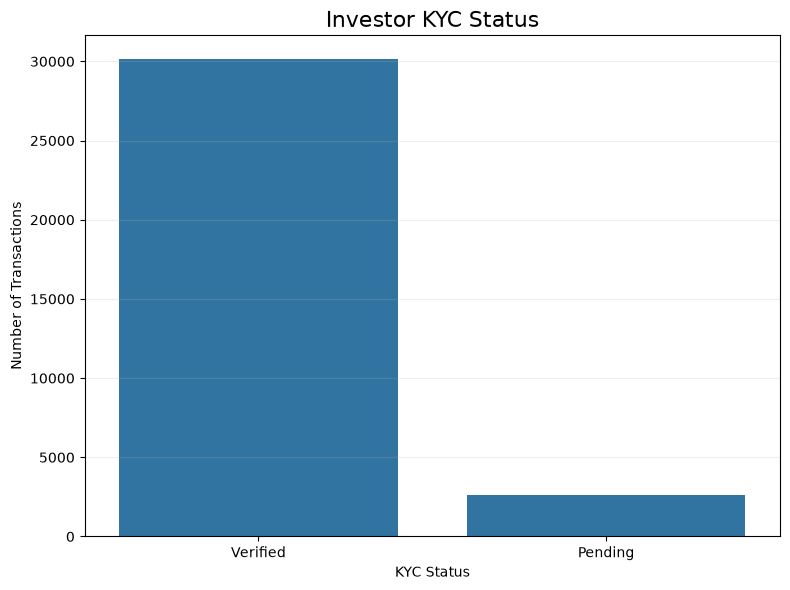

In [29]:
# Chart 8: KYC Status Distribution

kyc_counts = transactions["kyc_status"].value_counts()

plt.figure(figsize=(8, 6))

sns.barplot(
    x=kyc_counts.index,
    y=kyc_counts.values,
    errorbar=None
)

plt.title("Investor KYC Status", fontsize=16)
plt.xlabel("KYC Status")
plt.ylabel("Number of Transactions")

plt.grid(axis="y", alpha=0.2)
plt.tight_layout()

plt.savefig(
    "../reports/charts/08_kyc_status_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Investor Demographics — Key Findings

- The 26–35 age group has the highest number of transaction records, with 13,463 transactions.
- The 36–45 age group is the second-largest, with 8,146 transactions.
- Male investors account for 21,809 transaction records, while female investors account for 10,969.
- The average annual income represented in the transaction dataset is approximately ₹26.18 lakh.
- The median annual income is approximately ₹19.7 lakh.
- KYC verification is high, with 30,146 records marked as Verified compared with 2,632 marked as Pending.
- The demographic analysis indicates that the transaction dataset is concentrated among younger working-age investors, particularly the 26–35 group.


In [30]:
# Geographic analysis - State level

state_sip = (
    transactions.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

print("Top states by transaction amount:")
print(state_sip.head(10))

Top states by transaction amount:
state
Punjab            315780459
Tamil Nadu        315177237
Madhya Pradesh    308312493
Rajasthan         298645822
Gujarat           298358940
West Bengal       297182514
Telangana         290219284
Delhi             289633404
Uttar Pradesh     285368873
Haryana           279634354
Name: amount_inr, dtype: int64


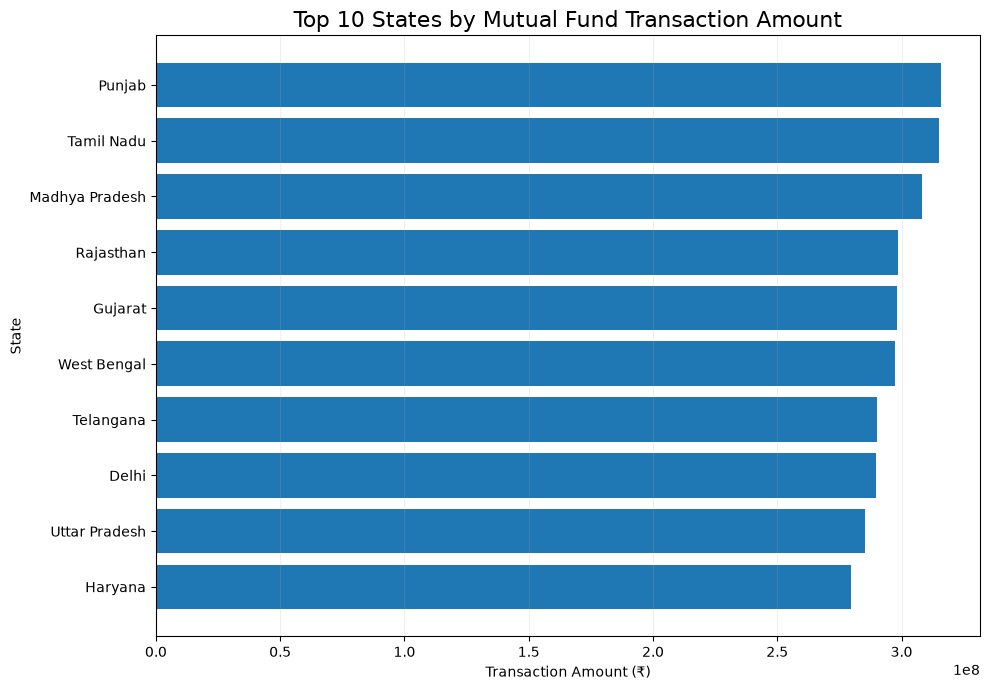

In [31]:
# Chart 9: Transaction Amount by State

top_states = state_sip.head(10).sort_values()

plt.figure(figsize=(10, 7))

plt.barh(
    top_states.index,
    top_states.values
)

plt.title(
    "Top 10 States by Mutual Fund Transaction Amount",
    fontsize=16
)

plt.xlabel("Transaction Amount (₹)")
plt.ylabel("State")

plt.grid(axis="x", alpha=0.2)
plt.tight_layout()

plt.savefig(
    "../reports/charts/09_state_transaction_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [32]:
# City-level analysis

city_sip = (
    transactions.groupby("city")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

print("Top 10 cities by transaction amount:")
print(city_sip.head(10))

Top 10 cities by transaction amount:
city
Kolkata       297182514
Hyderabad     290219284
Gurugram      223778908
Coimbatore    170345165
Bhopal        165606495
Ahmedabad     160916535
Amritsar      159315652
Chandigarh    156464807
Jaipur        153768697
Faridabad     148078011
Name: amount_inr, dtype: int64


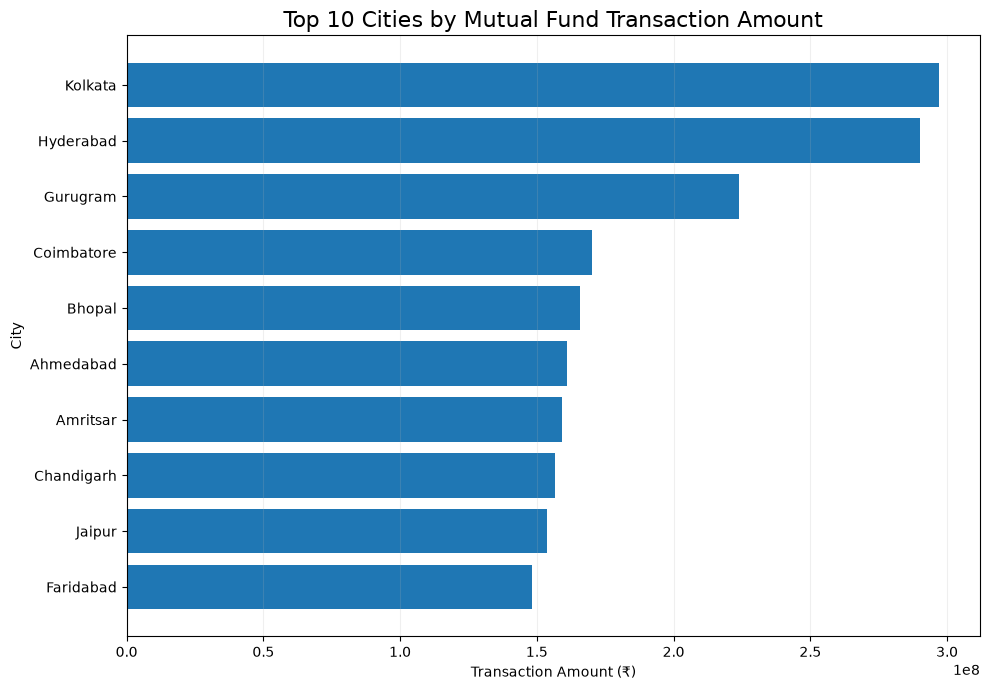

In [33]:
# Chart 10: Transaction Amount by City

top_cities = city_sip.head(10).sort_values()

plt.figure(figsize=(10, 7))

plt.barh(
    top_cities.index,
    top_cities.values
)

plt.title(
    "Top 10 Cities by Mutual Fund Transaction Amount",
    fontsize=16
)

plt.xlabel("Transaction Amount (₹)")
plt.ylabel("City")

plt.grid(axis="x", alpha=0.2)
plt.tight_layout()

plt.savefig(
    "../reports/charts/10_city_transaction_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [34]:
# City tier analysis

tier_sip = (
    transactions.groupby("city_tier")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

print("Transaction amount by city tier:")
print(tier_sip)

Transaction amount by city tier:
city_tier
T30    2319254790
B30    1202325640
Name: amount_inr, dtype: int64


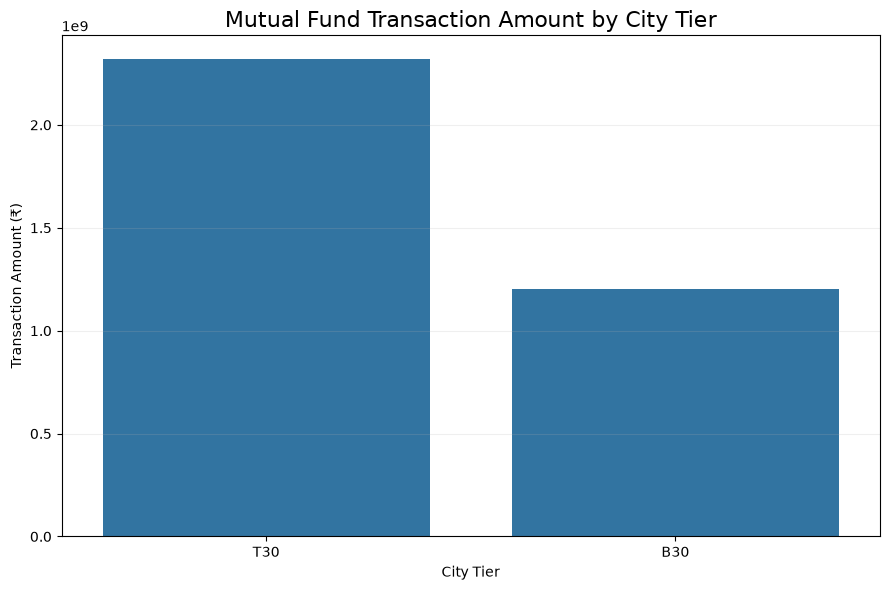

In [35]:
# Chart 11: Transaction Amount by City Tier

plt.figure(figsize=(9, 6))

sns.barplot(
    x=tier_sip.index,
    y=tier_sip.values,
    errorbar=None
)

plt.title(
    "Mutual Fund Transaction Amount by City Tier",
    fontsize=16
)

plt.xlabel("City Tier")
plt.ylabel("Transaction Amount (₹)")

plt.grid(axis="y", alpha=0.2)
plt.tight_layout()

plt.savefig(
    "../reports/charts/11_city_tier_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [36]:
print(state_sip.head(10))
print(city_sip.head(10))
print(tier_sip)

state
Punjab            315780459
Tamil Nadu        315177237
Madhya Pradesh    308312493
Rajasthan         298645822
Gujarat           298358940
West Bengal       297182514
Telangana         290219284
Delhi             289633404
Uttar Pradesh     285368873
Haryana           279634354
Name: amount_inr, dtype: int64
city
Kolkata       297182514
Hyderabad     290219284
Gurugram      223778908
Coimbatore    170345165
Bhopal        165606495
Ahmedabad     160916535
Amritsar      159315652
Chandigarh    156464807
Jaipur        153768697
Faridabad     148078011
Name: amount_inr, dtype: int64
city_tier
T30    2319254790
B30    1202325640
Name: amount_inr, dtype: int64


## Geographic Distribution — Key Findings

- Punjab recorded the highest total transaction amount among the states in the dataset at approximately ₹31.58 crore.
- Tamil Nadu followed closely at approximately ₹31.52 crore.
- Kolkata recorded the highest transaction amount among the listed cities at approximately ₹29.72 crore.
- T30 cities accounted for approximately ₹231.93 crore in transaction value, compared with approximately ₹120.23 crore for B30 cities.
- The transaction value from T30 cities was substantially higher than that from B30 cities.
- The geographic analysis highlights differences in mutual fund transaction activity across states, cities, and city tiers.
